In [7]:
# Clean reinstall of numpy and gensim
!pip uninstall -y numpy gensim
!pip install numpy==1.24.4  # Known to work well with gensim
!pip install gensim

Found existing installation: numpy 1.24.4
Uninstalling numpy-1.24.4:
  Successfully uninstalled numpy-1.24.4
  Using cached numpy-1.24.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.6 kB)
Using cached numpy-1.24.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.3 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
statsmodels 0.14.4 requires scipy!=1.9.2,>=1.8, which is not installed.
pytensor 2.30.3 requires scipy<2,>=1, which is not installed.
scikit-learn 1.6.1 requires scipy>=1.6.0, which is not installed.
clarabel 0.10.0 requires scipy, which is not installed.
sentence-transformers 3.4.1 requires scipy, which is not installed.
plotnine 0.14.5 requires scipy>=1.8.0, which is not installed.
albumentations 2.0.6 requires scipy>=1.10.0, which is not installed.
osqp 1.0.3 requires scipy>=0.13.2, which is not installed.
m

  Using cached gensim-4.3.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.1 kB)
  Using cached scipy-1.13.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
Using cached gensim-4.3.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (26.7 MB)
Using cached scipy-1.13.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (38.6 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.5.2 requires numpy>=1.25, but you have numpy 1.24.4 which is incompatible.
jaxlib 0.5.1 requires numpy>=1.25, but you have numpy 1.24.4 which is incompatible.
pymc 5.22.0 requires numpy>=1.25.0, but you have numpy 1.24.4 which is incompatible.


# Word2Vec Tutorial

We're using the [Coronavirus Tweets Dataset](https://www.kaggle.com/datatattle/covid-19-nlp-text-classification) from Kaggle for this tutorial. You can check out my [medium article](https://medium.com/@manansuri/a-dummys-guide-to-word2vec-456444f3c673) that complements this.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from gensim.models import Word2Vec

In [32]:
print("Numpy version:", np.__version__)
print("Gensim version:", gensim.__version__)

Numpy version: 1.24.4
Gensim version: 4.3.3


## Importing the Dataset + Text Preprocessing

In [2]:
# dataset = pd.read_csv('Corona_NLP_train.csv', encoding='latin1')
dataset = pd.read_csv('/content/sample_data/Corona_NLP_train.csv', encoding='latin1')

Very basic text preproccessing by removing punctuations, numbers. We have also cleaned the data by removing characters including and after 'https' in the text.

In [3]:
import re
texts=[]
for i in range(0,len(dataset)):
  text = re.sub('[^a-zA-Z]' , ' ', dataset['OriginalTweet'][i])
  text = text.lower()
  text = text.split()
  x = len(text) if text.count('https') ==0  else text.index('https')
  text = text[: x ]
  text = [t for t in text if not t=='https']
  text = ' '.join(text)
  texts.append(text)

Size of the dataset.

In [43]:
print(len(texts))
print(texts[:30])

41157
['menyrbie phil gahan chrisitv', 'advice talk to your neighbours family to exchange phone numbers create contact list with phone numbers of neighbours schools employer chemist gp set up online shopping accounts if poss adequate supplies of regular meds but not over order', 'coronavirus australia woolworths to give elderly disabled dedicated shopping hours amid covid outbreak', 'my food stock is not the only one which is empty please don t panic there will be enough food for everyone if you do not take more than you need stay calm stay safe covid france covid covid coronavirus confinement confinementotal confinementgeneral', 'me ready to go at supermarket during the covid outbreak not because i m paranoid but because my food stock is litteraly empty the coronavirus is a serious thing but please don t panic it causes shortage coronavirusfrance restezchezvous stayathome confinement', 'as news of the region s first confirmed covid case came out of sullivan county last week people flo

## Training the word2vec model

In [46]:
sentences = [line.split() for line in texts]
print(len(sentences))
print(sentences[0:3])

41157
[['menyrbie', 'phil', 'gahan', 'chrisitv'], ['advice', 'talk', 'to', 'your', 'neighbours', 'family', 'to', 'exchange', 'phone', 'numbers', 'create', 'contact', 'list', 'with', 'phone', 'numbers', 'of', 'neighbours', 'schools', 'employer', 'chemist', 'gp', 'set', 'up', 'online', 'shopping', 'accounts', 'if', 'poss', 'adequate', 'supplies', 'of', 'regular', 'meds', 'but', 'not', 'over', 'order'], ['coronavirus', 'australia', 'woolworths', 'to', 'give', 'elderly', 'disabled', 'dedicated', 'shopping', 'hours', 'amid', 'covid', 'outbreak']]


In [47]:
# w2v = Word2Vec(sentences, size=100, window=5, workers=4, iter=10, min_count=5)
w2v = Word2Vec(sentences=sentences, vector_size=100, window=5, workers=4, epochs=10, min_count=5)

## Working with word2vec

Finding the vocabulary of the model can be useful in several general applications, and in this case, provides us with a list of words we can try and use other functions.

In [12]:
# words = list(w2v.wv.vocab)
words = list(w2v.wv.index_to_key)

In [48]:
print(len(words))
print(words[:30])

10630
['the', 'to', 'and', 'of', 'covid', 'a', 'in', 'coronavirus', 'for', 'is', 'are', 'i', 'you', 'on', 's', 'this', 'prices', 'at', 'it', 'food', 'supermarket', 'we', 'store', 'that', 'with', 'grocery', 'have', 'as', 'be', 'people']


Finding the embedding of a given word can be useful when we’re trying to represent sentences as a collection of word embeddings, like when we’re trying to make a weight matrix for the embedding layer of a network.

In [15]:
print( w2v.wv['computer'] )

[ 0.25185835 -0.03916693  0.06744564 -0.00972919 -0.12079142 -0.22654574
 -0.12030316  0.16916215  0.03615291  0.07597224 -0.2238522  -0.00961027
 -0.03989084  0.2821554   0.4123359  -0.05758246  0.39034155 -0.244042
 -0.05918383 -0.505551    0.45597878 -0.04594945  0.21888848 -0.15543942
 -0.1869746  -0.03134017 -0.40461764 -0.16643868  0.11299856 -0.02749342
  0.206804    0.08216652 -0.13377514 -0.1435994   0.0076607   0.0494515
 -0.3942308  -0.34626853 -0.0902788  -0.2649226  -0.26332662 -0.11571891
 -0.04508799 -0.0656644   0.25091285 -0.04725145 -0.12433949 -0.04217008
  0.02846637  0.27936062  0.09612728 -0.05921679 -0.09218448 -0.06441316
 -0.14849769  0.05384271 -0.03069577  0.14752847 -0.04646511  0.10195262
 -0.02689613  0.06249193  0.01674613 -0.09049495 -0.49426645  0.21295528
 -0.07222143  0.38332322  0.10412972  0.20119153 -0.13791077 -0.05855954
  0.09232951 -0.1543692  -0.04766455  0.06318913 -0.20952305 -0.06491625
 -0.13796522 -0.05495204 -0.1015671  -0.13779424 -0.10

We can also find out the similarity between given words (the cosine distance between their vectors).

In [16]:
w2v.wv.similarity('vladimir', 'putin')

0.78060794

In [17]:
w2v.wv.similarity('vladimir', 'modi')

0.65927964

With the gensim, we can also find the most similar words to a given word.

In [18]:
print(w2v.wv.most_similar('pay'))

[('paying', 0.6709027290344238), ('paid', 0.6396351456642151), ('wages', 0.6388454437255859), ('raise', 0.6012771129608154), ('bills', 0.5882498025894165), ('rent', 0.5710300803184509), ('benefits', 0.5693299174308777), ('wage', 0.5615403056144714), ('cancel', 0.5589721202850342), ('tax', 0.5589256286621094)]


In [19]:
print(w2v.wv.most_similar('covid'))

[('coronavirus', 0.6126343011856079), ('virus', 0.5173803567886353), ('corona', 0.4866648018360138), ('epidemic', 0.44603675603866577), ('coronavirusoutbreakindia', 0.4439988136291504), ('disease', 0.44210365414619446), ('coronavirusindia', 0.43852126598358154), ('coronacrisis', 0.4248424768447876), ('corvid', 0.41297441720962524), ('coronavirusnyc', 0.4115943908691406)]


In [20]:
print(w2v.wv.most_similar('india'))

[('pakistan', 0.7348019480705261), ('nigeria', 0.724966824054718), ('kenya', 0.6394578814506531), ('iran', 0.6275816559791565), ('ji', 0.6268583536148071), ('delhi', 0.6255389451980591), ('donaldtrump', 0.6241405606269836), ('imf', 0.6232710480690002), ('amitshah', 0.6165701746940613), ('drharshvardhan', 0.6158382892608643)]


Similarly, we can use the same function to find analogies of the form: if x:y, then z:?. Here we enter the known relation x,y in the positive parameter, and the term who’s analogy has to be found in the negative parameter.

In [21]:
print(w2v.wv.most_similar(positive=['russian', 'russia'], negative=['arab']))

[('saudi', 0.7888044714927673), ('arabia', 0.7795760631561279), ('putin', 0.7582232356071472), ('trump', 0.7003181576728821), ('opec', 0.698294997215271), ('agreed', 0.6778793931007385), ('donald', 0.6371164321899414), ('saudis', 0.6143104434013367), ('output', 0.6035207509994507), ('pres', 0.5985197424888611)]


We also have this method which works similar to an "odd one out" situation.

In [22]:
w2v.wv.doesnt_match(['grocery', 'covid', 'coronavirus'])

'grocery'

## Visualising word vectors

Word2Vec word embedding can usually be of sizes 100 or 300, and it is practically not possible to visualise a 300 or 100 dimensional space with meaningful outputs. I used this [snippet](http://web.stanford.edu/class/cs224n/materials/Gensim%20word%20vector%20visualization.html) from [Stanford’s 224n course site](http://web.stanford.edu/class/cs224n/index.html#schedule), which basically provides you the option of either using a list of words, or providing the number of random samples you want to be displayed. In either case, it uses PCA to reduce the dimensionality and represent the word through their vectors on a 2-dimensional plane. The actual values of the axis are not of concern as they do not hold any significance, rather we can use it to perceive similar vectors to be densely located with respect to each other.


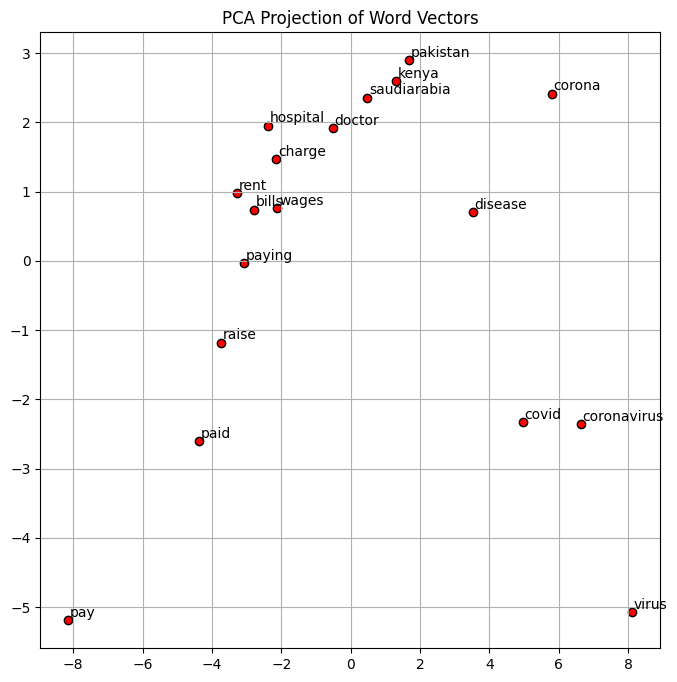

In [26]:
#using PCA
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def display_pca_scatterplot(model, words=None, sample=0):
    if words is None:
        if sample > 0:
            words = np.random.choice(list(model.wv.index_to_key), sample, replace=False)
        else:
            words = list(model.wv.index_to_key)

    # Filter out words not in the vocabulary
    words = [word for word in words if word in model.wv]

    word_vectors = np.array([model.wv[word] for word in words])

    twodim = PCA(n_components=2).fit_transform(word_vectors)

    plt.figure(figsize=(8, 8))
    plt.scatter(twodim[:, 0], twodim[:, 1], edgecolors='k', c='r')
    for word, (x, y) in zip(words, twodim):
        plt.text(x + 0.05, y + 0.05, word)
    plt.title("PCA Projection of Word Vectors")
    plt.grid(True)
    plt.show()

# Example usage
display_pca_scatterplot(w2v, [
    'coronavirus', 'covid', 'virus', 'corona', 'disease',
    'saudiarabia', 'doctor', 'hospital', 'pakistan', 'kenya',
    'pay', 'paying', 'paid', 'wages', 'raise', 'bills', 'rent', 'charge'
])


Perplexity too high, adjusting to 6


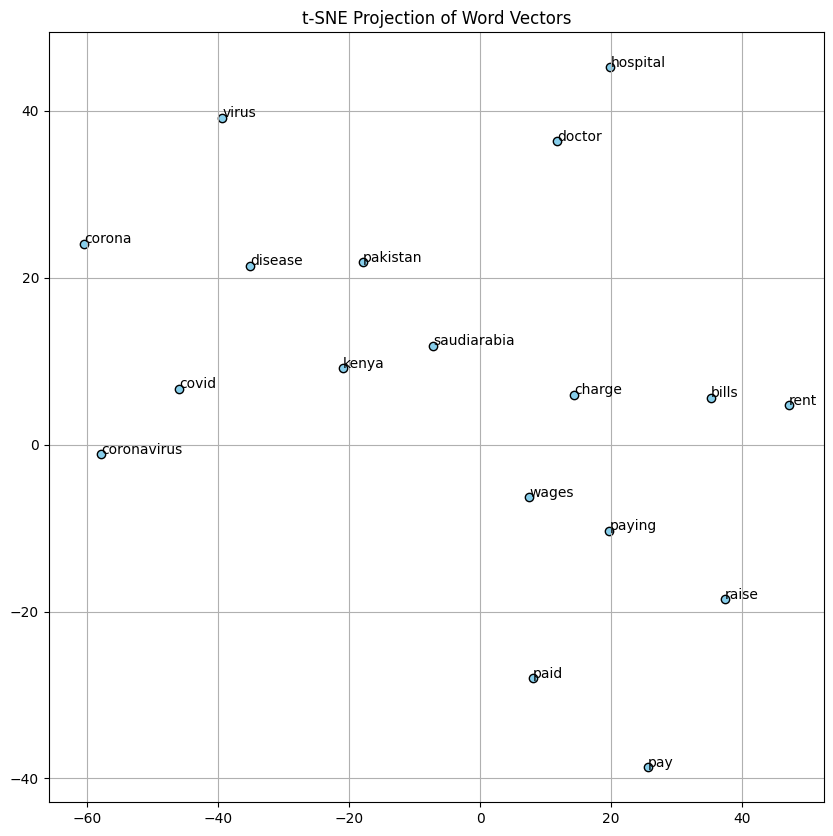

In [34]:
# t-SNE
from sklearn.manifold import TSNE

def display_tsne_scatterplot(model, words=None, sample=0, perplexity=30):
    if words is None:
        words = np.random.choice(model.wv.index_to_key, sample, replace=False) if sample > 0 else model.wv.index_to_key
    words = [word for word in words if word in model.wv]

    word_vectors = np.array([model.wv[word] for word in words])
    n_samples = len(word_vectors)

    if perplexity >= n_samples:
        perplexity = max(5, n_samples // 3)  # Set to a safe lower value
        print(f"Perplexity too high, adjusting to {perplexity}")

    tsne = TSNE(n_components=2, perplexity=perplexity, max_iter=1000, random_state=42)
    twodim = tsne.fit_transform(word_vectors)

    plt.figure(figsize=(10, 10))
    plt.scatter(twodim[:, 0], twodim[:, 1], edgecolors='k', c='skyblue')
    for word, (x, y) in zip(words, twodim):
        plt.text(x + 0.05, y + 0.05, word)
    plt.title("t-SNE Projection of Word Vectors")
    plt.grid(True)
    plt.show()

display_tsne_scatterplot(w2v, [
    'coronavirus', 'covid', 'virus', 'corona', 'disease',
    'saudiarabia', 'doctor', 'hospital', 'pakistan', 'kenya',
    'pay', 'paying', 'paid', 'wages', 'raise', 'bills', 'rent', 'charge'
])

# Save the model
We can save our existing models and load them again.


In [41]:
w2v.save("word2vec.model")

In [50]:
model = Word2Vec.load("word2vec.model")
print(model.wv.most_similar('covid'))

[('coronavirus', 0.6126343011856079), ('virus', 0.5173803567886353), ('corona', 0.4866648018360138), ('epidemic', 0.44603675603866577), ('coronavirusoutbreakindia', 0.4439988136291504), ('disease', 0.44210365414619446), ('coronavirusindia', 0.43852126598358154), ('coronacrisis', 0.4248424768447876), ('corvid', 0.41297441720962524), ('coronavirusnyc', 0.4115943908691406)]


**Further train the existing model**

This adds more training on top of your existing model, which is useful if:
- You want to fine-tune on new domain-specific words
- You want to include new word co-occurrence patterns

In this case:
- You’re training the model with a single new sentence: ["hello", "world"]
- total_examples=1 means you're passing one sentence
- epochs=1 means the sentence is trained once

In [ ]:
model.train([["hello", "world"]], total_examples=1, epochs=1)

## Importing pre trained embeddings

Gensim comes with several already pre-trained models, in the Gensim-data repository. We can import the downloader from the gensim library. We can use the following method to print the list of pre-trained models trained on large datasets available to us. This also  includes models like GloVe and fastext other than word2vec.



In [27]:
import gensim.downloader
print(list(gensim.downloader.info()['models'].keys()))

['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis']


Here we have used  'word2vec-google-news-300' (trained on google-news, size is 300), and found words similar to ‘twitter’.

In [28]:
google_news = gensim.downloader.load('word2vec-google-news-300') # This took 10 minutes on colab
google_news.most_similar('twitter')

[==================================================] 100.0% 1662.8/1662.8MB downloaded


[('Twitter', 0.8908904194831848),
 ('Twitter.com', 0.7536780834197998),
 ('tweet', 0.7431626319885254),
 ('tweeting', 0.7161932587623596),
 ('tweeted', 0.7137226462364197),
 ('facebook', 0.6988551616668701),
 ('tweets', 0.6974530816078186),
 ('Tweeted', 0.6950210928916931),
 ('Tweet', 0.6875007152557373),
 ('Tweeting', 0.6845167279243469)]